In [1]:
import icechunk
import xarray as xr
from srm import catalog
import duckdb
import geopandas as gpd
import rasterix
import numpy as np
from rasterix.rasterize.rasterio import geometry_clip
import matplotlib.pyplot as plt
import seaborn as sns
from ibicus.debias import QuantileMapping

# import matplotlib.style as mplstyle
# mplstyle.use('fast')

In [2]:
catalog

Dataset Catalog (6 datasets)
--------------------------------------------------------------------------------
CESM-WACCM-Historical-icechunk | icechunk   | s3://carbonplan-srm/input/tensor/CESM2-WACCM-Historical/icechunk/icechunk
CESM-WACCM-Historical-virtual | icechunk   | s3://carbonplan-srm/input/tensor/CESM2-WACCM-Historical/icechunk/virtual_icechunk
CESM-WACCM-G6-1.5K-icechunk | icechunk   | s3://carbonplan-srm/input/tensor/CESM-WACCM-G6-1.5K/icechunk/icechunk
CESM-WACCM-G6-1.5K-virtual | icechunk   | s3://carbonplan-srm/input/tensor/CESM-WACCM-G6-1.5K/icechunk/virtual_icechunk
CESM2-WACCM-SSP245-icechunk | icechunk   | s3://carbonplan-srm/input/tensor/CESM2-WACCM-SSP245/icechunk/icechunk
ERA5                 | icechunk   | s3://carbonplan-srm/input/tensor/era5_rechunked_resampled.icechunk

# Get data

### Output from three climate model simulations

These simulations were conducted in the Community Earth System Model version 2 -- Whole Atmosphere Community Climate Model (CESM2-WACCM)
* Historical (1978 - 2014)
* SSP245 (2015 - 2070)
* G6-1.5K (2035 - 2085)

In [3]:
var_cesm = "TREFHT"
var_era5 = "2m_temperature"
unit_conv_cesm_to_era5 = 1

In [4]:
def fix_coords(ds: xr.Dataset):
    ds.coords["lon"] = (ds.coords["lon"] + 180) % 360 - 180
    ds = ds.sortby(ssp245.lon)
    return ds

In [5]:
ssp245_cat = catalog.get("CESM2-WACCM-SSP245-icechunk")

ssp245_storage = icechunk.s3_storage(
    bucket=ssp245_cat.bucket,
    prefix=ssp245_cat.prefix,
    from_env=True,
)
ssp245_repo = icechunk.Repository.open(ssp245_storage)
ssp245_session = ssp245_repo.readonly_session("main")
ssp245 = xr.open_zarr(ssp245_session.store, consolidated=False)
ssp245 = fix_coords(ssp245)
ssp245 = ssp245.proj.assign_crs(spatial_ref="epsg:4326")

In [6]:
model_historical_cat = catalog.get("CESM-WACCM-Historical-icechunk")

model_historical_storage = icechunk.s3_storage(
    bucket=model_historical_cat.bucket,
    prefix=model_historical_cat.prefix,
    from_env=True,
)
model_historical_repo = icechunk.Repository.open(model_historical_storage)
model_historical_session = model_historical_repo.readonly_session("main")
model_historical = xr.open_zarr(model_historical_session.store, consolidated=False)
model_historical = fix_coords(model_historical)

In [7]:
g61pt5k_cat = catalog.get("CESM-WACCM-G6-1.5K-icechunk")

g61pt5k_storage = icechunk.s3_storage(
    bucket=g61pt5k_cat.bucket,
    prefix=g61pt5k_cat.prefix,
    from_env=True,
)
g61pt5k_repo = icechunk.Repository.open(g61pt5k_storage)
g61pt5k_session = g61pt5k_repo.readonly_session("main")
g61pt5k = xr.open_zarr(g61pt5k_session.store, consolidated=False)
g61pt5k = fix_coords(g61pt5k)
g61pt5k = g61pt5k.isel(ensemble_member=0)

### Observations: ERA5

In [8]:
era5_cat = catalog.get("ERA5")
era5_storage = icechunk.s3_storage(
    bucket=era5_cat.bucket,
    prefix=era5_cat.prefix,
    from_env=True,
)
era5_repo = icechunk.Repository.open(era5_storage)
era5_session = era5_repo.readonly_session("main")
era5 = xr.open_zarr(era5_session.store).pipe(rasterix.assign_index)
era5 = era5.proj.assign_crs(spatial_ref="epsg:4326")

### Shapefiles and coordinates for subsetting to South Africa and Cape Town

In [9]:
df = duckdb.sql(
    """install httpfs; load httpfs; install spatial; load spatial; SELECT name, ST_AsText(geom) as geometry FROM ST_Read('https://carbonplan-data.s3.us-west-2.amazonaws.com/countries-50m.json') WHERE NAME = 'South Africa'"""
).df()
df["geometry"] = gpd.GeoSeries.from_wkt(df["geometry"])
south_africa_geom = gpd.GeoDataFrame(df, geometry="geometry")

lon_min, lat_min, lon_max, lat_max = south_africa_geom.total_bounds
lon_min = lon_min - 2
lon_max = lon_max + 2
lat_min = lat_min - 2
lat_max = lat_max + 2

In [10]:
cities = gpd.read_file(
    "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_populated_places_simple.zip",
    columns=["name", "sov0name", "geometry"],
)
sa_cities = cities[cities["sov0name"] == "South Africa"]
cape_town_x, cape_town_y = (
    float(sa_cities[sa_cities["name"] == "Cape Town"].geometry.x),
    float(sa_cities[sa_cities["name"] == "Cape Town"].geometry.y),
)

/tmp/ipykernel_14117/1595652233.py:7: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  float(sa_cities[sa_cities["name"] == "Cape Town"].geometry.x),
/tmp/ipykernel_14117/1595652233.py:8: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  float(sa_cities[sa_cities["name"] == "Cape Town"].geometry.y),


# Process data to demo region and time period

### Subset data to demo region (South Africa)

In [11]:
era5_south_africa = geometry_clip(
    era5, south_africa_geom[["geometry"]], xdim="longitude", ydim="latitude"
)

era5_south_africa_bounds = era5.sel(
    longitude=slice(lon_min, lon_max),
    latitude=slice(lat_max, lat_min),  # Note: descending order for latitude
)

In [12]:
model_historical_south_africa_bounds = (
    model_historical.sortby("lat", ascending=False)
    .sel(
        lon=slice(lon_min, lon_max),
        lat=slice(lat_max, lat_min),  # Note: descending order for latitude
    )
    .load()
)

model_historical_south_africa = geometry_clip(
    model_historical.sortby("lat", ascending=False),
    south_africa_geom[["geometry"]],
    xdim="lon",
    ydim="lat",
).load()

In [13]:
ssp245_south_africa_bounds = ssp245.sortby("lat", ascending=False).sel(
    lon=slice(lon_min, lon_max),
    lat=slice(lat_max, lat_min),  # Note: descending order for latitude
)

ssp245_south_africa = geometry_clip(
    ssp245.sortby("lat", ascending=False),
    south_africa_geom[["geometry"]],
    xdim="lon",
    ydim="lat",
)

In [14]:
g61pt5k_south_africa_bounds = g61pt5k.sortby("lat", ascending=False).sel(
    lon=slice(lon_min, lon_max),
    lat=slice(lat_max, lat_min),  # Note: descending order for latitude
)

g61pt5k_south_africa = geometry_clip(
    g61pt5k.sortby("lat", ascending=False),
    south_africa_geom[["geometry"]],
    xdim="lon",
    ydim="lat",
)

### Subset data to consistent time periods and variable names:
* Historical (for ERA5 and model historical): 1978-2014
* Future (for SSP245 and G6-1.5K): 2050-2070

In [15]:
ds_future_dict = {
    "ssp245": ssp245_south_africa_bounds,
    "ssp245_clipped": ssp245_south_africa,
    "g61pt5k": g61pt5k_south_africa_bounds,
    "g61pt5k_clipped": g61pt5k_south_africa,
}

ds_hist_dict = {
    "model_hist_clipped": model_historical_south_africa,
    "model_hist": model_historical_south_africa_bounds,
    "era5_clipped": era5_south_africa,
    "era5": era5_south_africa_bounds,
}

for key, ds in ds_future_dict.items():
    ds = ds.where(ds["time.year"] >= 2050, drop=True)
    ds = ds.where(ds["time.year"] < 2070, drop=True)
    ds_future_dict[key] = ds[var_cesm] * unit_conv_cesm_to_era5

for key, ds in ds_hist_dict.items():
    ds = ds.where(ds["time.year"] >= 1978, drop=True)
    ds = ds.where(ds["time.year"] < 2015, drop=True)
    if key in ["model_hist", "model_hist_clipped"]:
        ds_hist_dict[key] = ds[var_cesm] * unit_conv_cesm_to_era5
    else:
        ds_hist_dict[key] = ds[var_era5]

dict_all = ds_future_dict | ds_hist_dict

In [16]:
for key, ds in dict_all.items():
    print(key)
    print(
        "Years: "
        + str(np.nanmin(ds["time.year"]))
        + " - "
        + str(np.nanmax(ds["time.year"]))
    )

ssp245
Years: 2050 - 2069
ssp245_clipped
Years: 2050 - 2069
g61pt5k
Years: 2050 - 2069
g61pt5k_clipped
Years: 2050 - 2069
model_hist_clipped
Years: 1978 - 2014
model_hist
Years: 1978 - 2014
era5_clipped
Years: 1978 - 2014
era5
Years: 1978 - 2014


### Look at raw input data in demo region

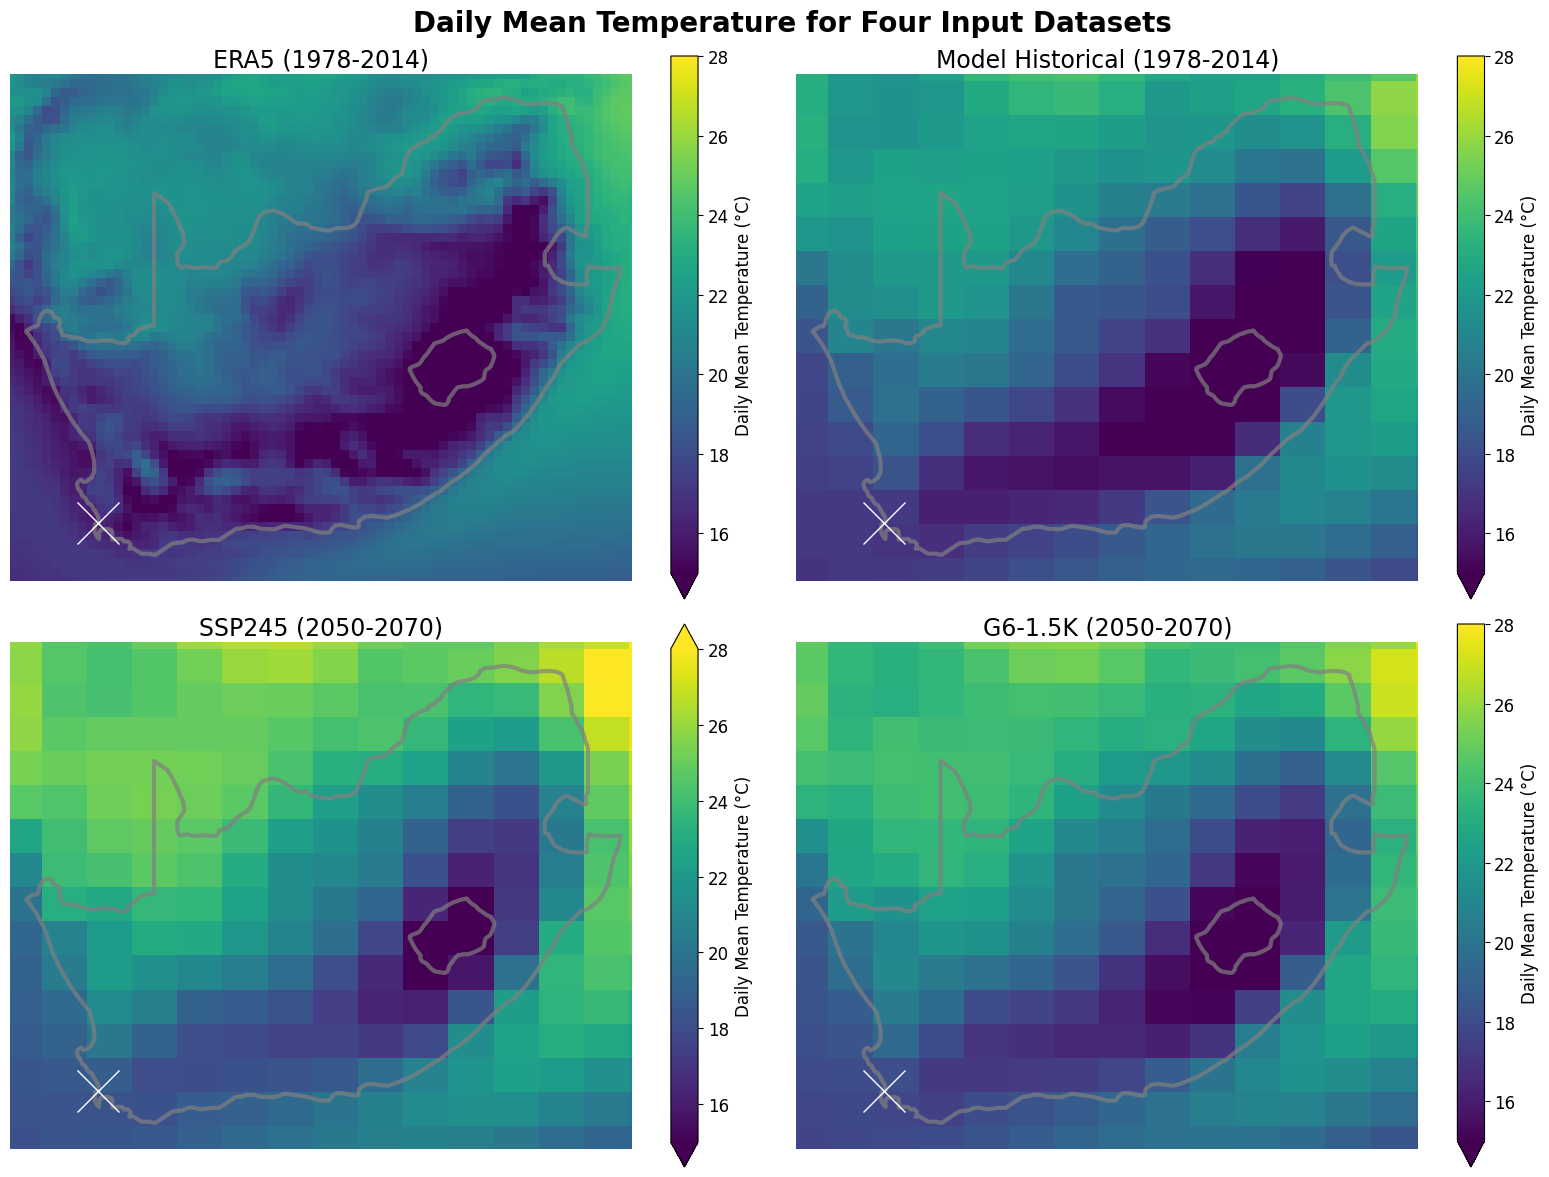

In [17]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
vmin = 15
vmax = 28

plt.rcParams["font.size"] = 12


def format_map_subplot(ax):
    south_africa_geom["geometry"].plot(
        ax=ax, facecolor="none", edgecolor="gray", linewidth=3, alpha=0.7
    )
    ax.set_xlim([16, 33.2])
    ax.set_ylim([-35.5, -21.5])
    ax.plot([cape_town_x], [cape_town_y], "xw", fillstyle="none", markersize=30)
    ax.axis("off")


# dataset key, dataset label, row #, column #
plots_info = [
    ("era5", "ERA5 (1978-2014)", 0, 0),
    ("model_hist", "Model Historical (1978-2014)", 0, 1),
    ("ssp245", "SSP245 (2050-2070)", 1, 0),
    ("g61pt5k", "G6-1.5K (2050-2070)", 1, 1),
]

for key, title, row, col in plots_info:
    ax = axes[row, col]
    (dict_all[key] - 273.15).mean(dim="time").plot(
        ax=ax,
        add_colorbar=True,
        vmin=vmin,
        vmax=vmax,
        cbar_kwargs={"label": "Daily Mean Temperature (°C)"},
    )
    format_map_subplot(ax)
    ax.set_title(title, fontsize=17)

fig.suptitle(
    "Daily Mean Temperature for Four Input Datasets", fontsize=20, fontweight="bold"
)

plt.tight_layout()
plt.show()

# Step 1: Bias correct coarse model data

### Prep data

In [18]:
dict_all["era5_coarse"] = dict_all["era5"].interp(
    longitude=dict_all["ssp245"].lon,
    latitude=dict_all["ssp245"].lat,
    method="linear",
)

### Initialize debiaser

In [19]:
debiaser = QuantileMapping.from_variable(variable="tas", mapping_type="nonparametric")

### Debias model output

In [20]:
tas_cm_hist_debiased = debiaser.apply(
    obs=dict_all["era5_coarse"].values,
    cm_hist=dict_all["model_hist"].values,
    cm_future=dict_all["model_hist"].values,
    time_obs=dict_all["era5_coarse"]["time"].values,
    time_cm_hist=dict_all["model_hist"]["time"].values,
)

g61pt5k_fut_debiased = debiaser.apply(
    obs=dict_all["era5_coarse"].values,
    cm_hist=dict_all["model_hist"].values,
    cm_future=dict_all["g61pt5k"].values,
    time_obs=dict_all["era5_coarse"]["time"].values,
    time_cm_hist=dict_all["model_hist"]["time"].values,
    time_cm_future=dict_all["g61pt5k"]["time"].values,
)

ssp245_fut_debiased = debiaser.apply(
    obs=dict_all["era5_coarse"].values,
    cm_hist=dict_all["model_hist"].values,
    cm_future=dict_all["ssp245"].values,
    time_obs=dict_all["era5_coarse"]["time"].values,
    time_cm_hist=dict_all["model_hist"]["time"].values,
    time_cm_future=dict_all["ssp245"]["time"].values,
)

100%|██████████| 620/620 [00:00<00:00, 862.30it/s]


### Process output to xarray and extract Cape Town time series

In [21]:
dict_all["model_hist_debiased"] = xr.DataArray(
    data=tas_cm_hist_debiased,
    coords={
        "lat": dict_all["model_hist"]["lat"],
        "lon": dict_all["model_hist"]["lon"],
        "time": dict_all["model_hist"]["time"],
    },
    dims=["time", "lat", "lon"],
)

dict_all["g61pt5k_debiased"] = xr.DataArray(
    data=g61pt5k_fut_debiased,
    coords={
        "lat": dict_all["g61pt5k"]["lat"],
        "lon": dict_all["g61pt5k"]["lon"],
        "time": dict_all["g61pt5k"]["time"],
    },
    dims=["time", "lat", "lon"],
)


dict_all["ssp245_debiased"] = xr.DataArray(
    data=ssp245_fut_debiased,
    coords={
        "lat": dict_all["ssp245"]["lat"],
        "lon": dict_all["ssp245"]["lon"],
        "time": dict_all["ssp245"]["time"],
    },
    dims=["time", "lat", "lon"],
)

In [22]:
list(dict_all.keys())

['ssp245',
 'ssp245_clipped',
 'g61pt5k',
 'g61pt5k_clipped',
 'model_hist_clipped',
 'model_hist',
 'era5_clipped',
 'era5',
 'era5_coarse',
 'model_hist_debiased',
 'g61pt5k_debiased',
 'ssp245_debiased']

In [23]:
dict_all_CT = {}
for key, ds in dict_all.items():
    if key in ["era5_clipped", "era5"]:
        ds_CT = ds.sel(latitude=cape_town_y, longitude=cape_town_x, method="nearest")
    else:
        ds_CT = ds.sel(lat=cape_town_y, lon=cape_town_x, method="nearest")
    dict_all_CT[key] = ds_CT

# Make figures of raw vs. debiased distributions at Cape Town

Text(0.5, 0, 'Daily mean temperature (°C)')

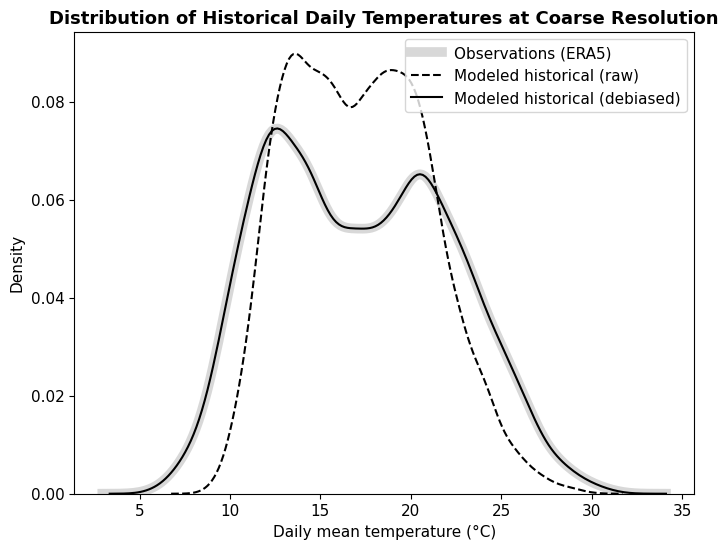

In [24]:
plt.figure(figsize=(8, 6))
plt.rcParams["font.size"] = 11

sns.kdeplot(
    dict_all_CT["era5_coarse"] - 273.15,
    label="Observations (ERA5)",
    color="gray",
    linewidth=7,
    alpha=0.3,
)
sns.kdeplot(
    dict_all_CT["model_hist"] - 273.15,
    label="Modeled historical (raw)",
    color="black",
    linestyle="--",
)
sns.kdeplot(
    dict_all_CT["model_hist_debiased"] - 273.15,
    label="Modeled historical (debiased)",
    color="black",
    linestyle="-",
)

plt.title(
    "Distribution of Historical Daily Temperatures at Coarse Resolution",
    fontsize=13,
    fontweight="bold",
)

plt.legend()
plt.xlabel("Daily mean temperature (°C)")

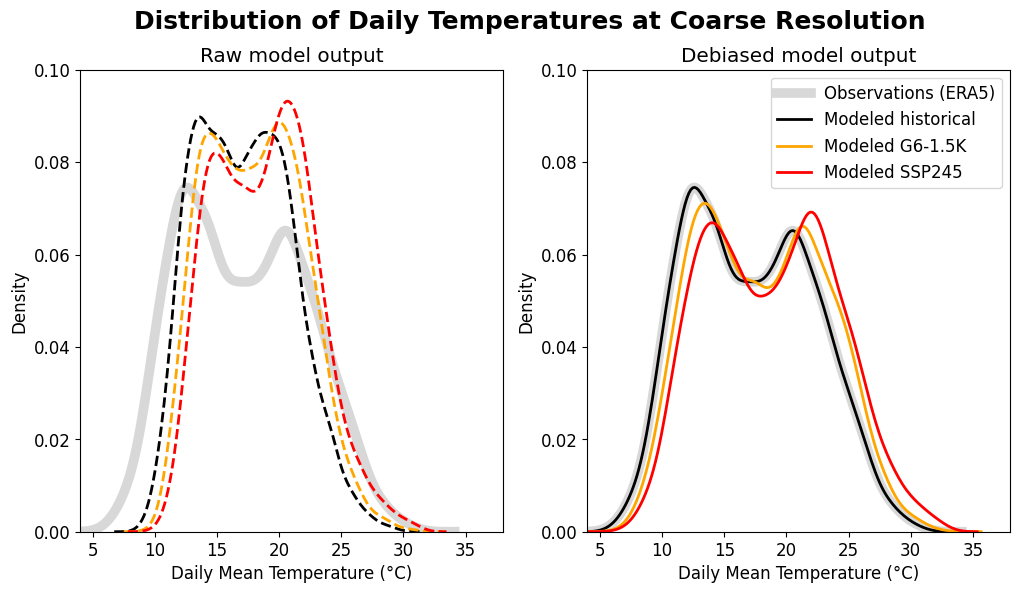

In [25]:
colors = ["black", "orange", "red"]
labels = ["Modeled historical", "Modeled G6-1.5K", "Modeled SSP245"]
dataset_keys = ["model_hist", "g61pt5k", "ssp245"]

plt.rcParams["font.size"] = 12


def format_subplot():
    sns.kdeplot(
        dict_all_CT["era5_coarse"] - 273.15,
        label="Observations (ERA5)",
        color="gray",
        linewidth=7,
        alpha=0.3,
        linestyle="-",
    )
    plt.ylim([0, 0.1])
    plt.xlim([4, 38])
    plt.xlabel("Daily Mean Temperature (°C)")


plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
format_subplot()
for i, key in enumerate(dataset_keys):
    sns.kdeplot(
        dict_all_CT[key] - 273.15,
        label=labels[i],
        color=colors[i],
        linewidth=2,
        linestyle="--",
    )
plt.title("Raw model output")


plt.subplot(1, 2, 2)
format_subplot()
for i, key in enumerate(dataset_keys):
    sns.kdeplot(
        dict_all_CT[key + "_debiased"] - 273.15,
        label=labels[i],
        color=colors[i],
        linewidth=2,
        linestyle="-",
    )
plt.title("Debiased model output")

plt.suptitle(
    "Distribution of Daily Temperatures at Coarse Resolution",
    fontsize=18,
    fontweight="bold",
)

plt.legend(fontsize=12)

# Step 2: downscale data to finer spatial scale

### Calculate anomaly spatial pattern
Calculate a fine-resolution spatial anomaly pattern derived from the observations

In [26]:
def calculate_error_map():
    era5_south_africa_bounds_coarse_reset = dict_all["era5_coarse"].reset_coords(
        ["longitude", "latitude"], drop=True
    )

    era5_coarse_on_fine_grid = era5_south_africa_bounds_coarse_reset.interp(
        lon=dict_all["era5"]["longitude"],
        lat=dict_all["era5"]["latitude"],
        method="linear",
    )
    error_map = dict_all["era5"].mean(dim="time") - era5_coarse_on_fine_grid.mean(
        dim="time"
    )

    return error_map

In [27]:
error_map = calculate_error_map()

### Downscale from coarse to fine scale
Spatially disaggregate from coarse-resolution to fine-resolution grid by bilinearly interpolating, then apply the fine-resolution spatial anomaly pattern derived from the observations

In [28]:
def downscale_from_coarse(da, error_map=error_map, fine_grid=dict_all["era5"]):
    da_fine_grid = da.interp(
        lon=fine_grid["longitude"],
        lat=fine_grid["latitude"],
        method="linear",
    )

    return da_fine_grid + error_map

In [29]:
dict_all["model_hist_debiased_downscaled"] = downscale_from_coarse(
    dict_all["model_hist_debiased"]
)

# Make maps of debiased and downscaled historical data

In [30]:
def format_map_subplot(ax):
    south_africa_geom["geometry"].plot(
        ax=ax, facecolor="none", edgecolor="gray", linewidth=3, alpha=0.7
    )
    ax.set_xlim([16, 33.2])
    ax.set_ylim([-35.5, -21.5])
    ax.plot([cape_town_x], [cape_town_y], "xk", markersize=30)

    ax.axis("off")


# dataset key, dataset label, row #, column #
plots_info = [
    ("model_hist", "Model historical (raw)", 0, 1),
    ("model_hist_debiased", "Model historical (debiased)", 0, 2),
    (
        "model_hist_debiased_downscaled",
        "Model historical (debiased + downscaled)",
        1,
        2,
    ),
    ("era5_coarse", "ERA5 (coarsened)", 0, 0),
    ("era5", "ERA5", 1, 0),
]

### Mean temperature across historical record

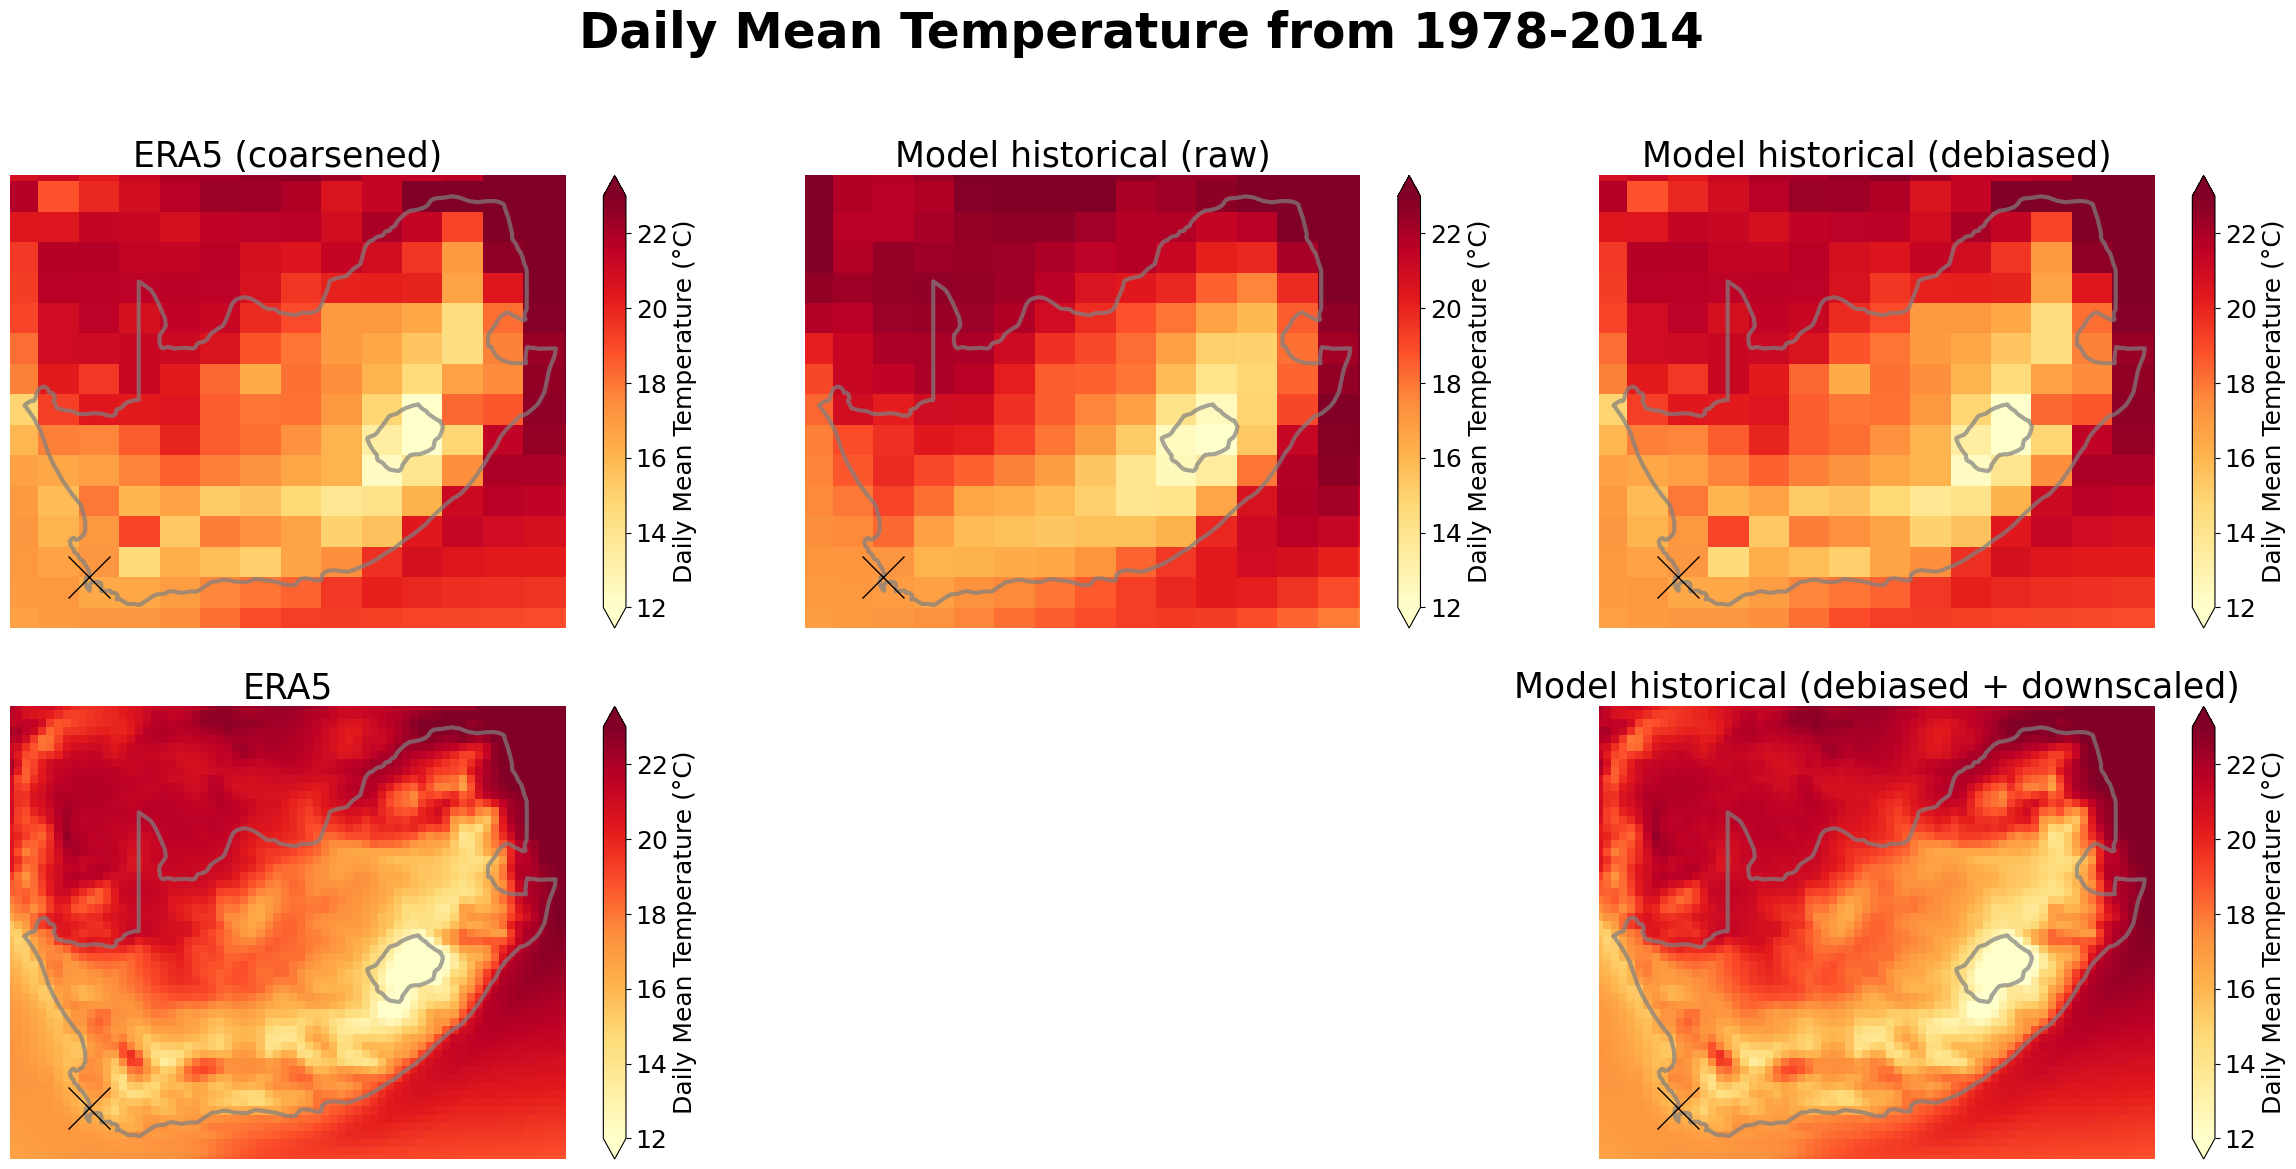

In [31]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(24, 12))
vmin = 12
vmax = 23
cmap = plt.cm.YlOrRd

plt.rcParams["font.size"] = 18

for key, title, row, col in plots_info:
    ax = axes[row, col]
    (dict_all[key] - 273.15).mean(dim="time").plot(
        ax=ax,
        cmap=cmap,
        add_colorbar=True,
        vmin=vmin,
        vmax=vmax,
        cbar_kwargs={"label": "Daily Mean Temperature (°C)"},
    )
    format_map_subplot(ax)
    ax.set_title(title, fontsize=25)

axes[1, 1].axis("off")

plt.suptitle("Daily Mean Temperature from 1978-2014", fontsize=35, fontweight="bold")

plt.tight_layout(rect=[0, 0, 1, 0.93], w_pad=1.5, h_pad=3)
plt.show()

### 95th percentile of daily temperatures

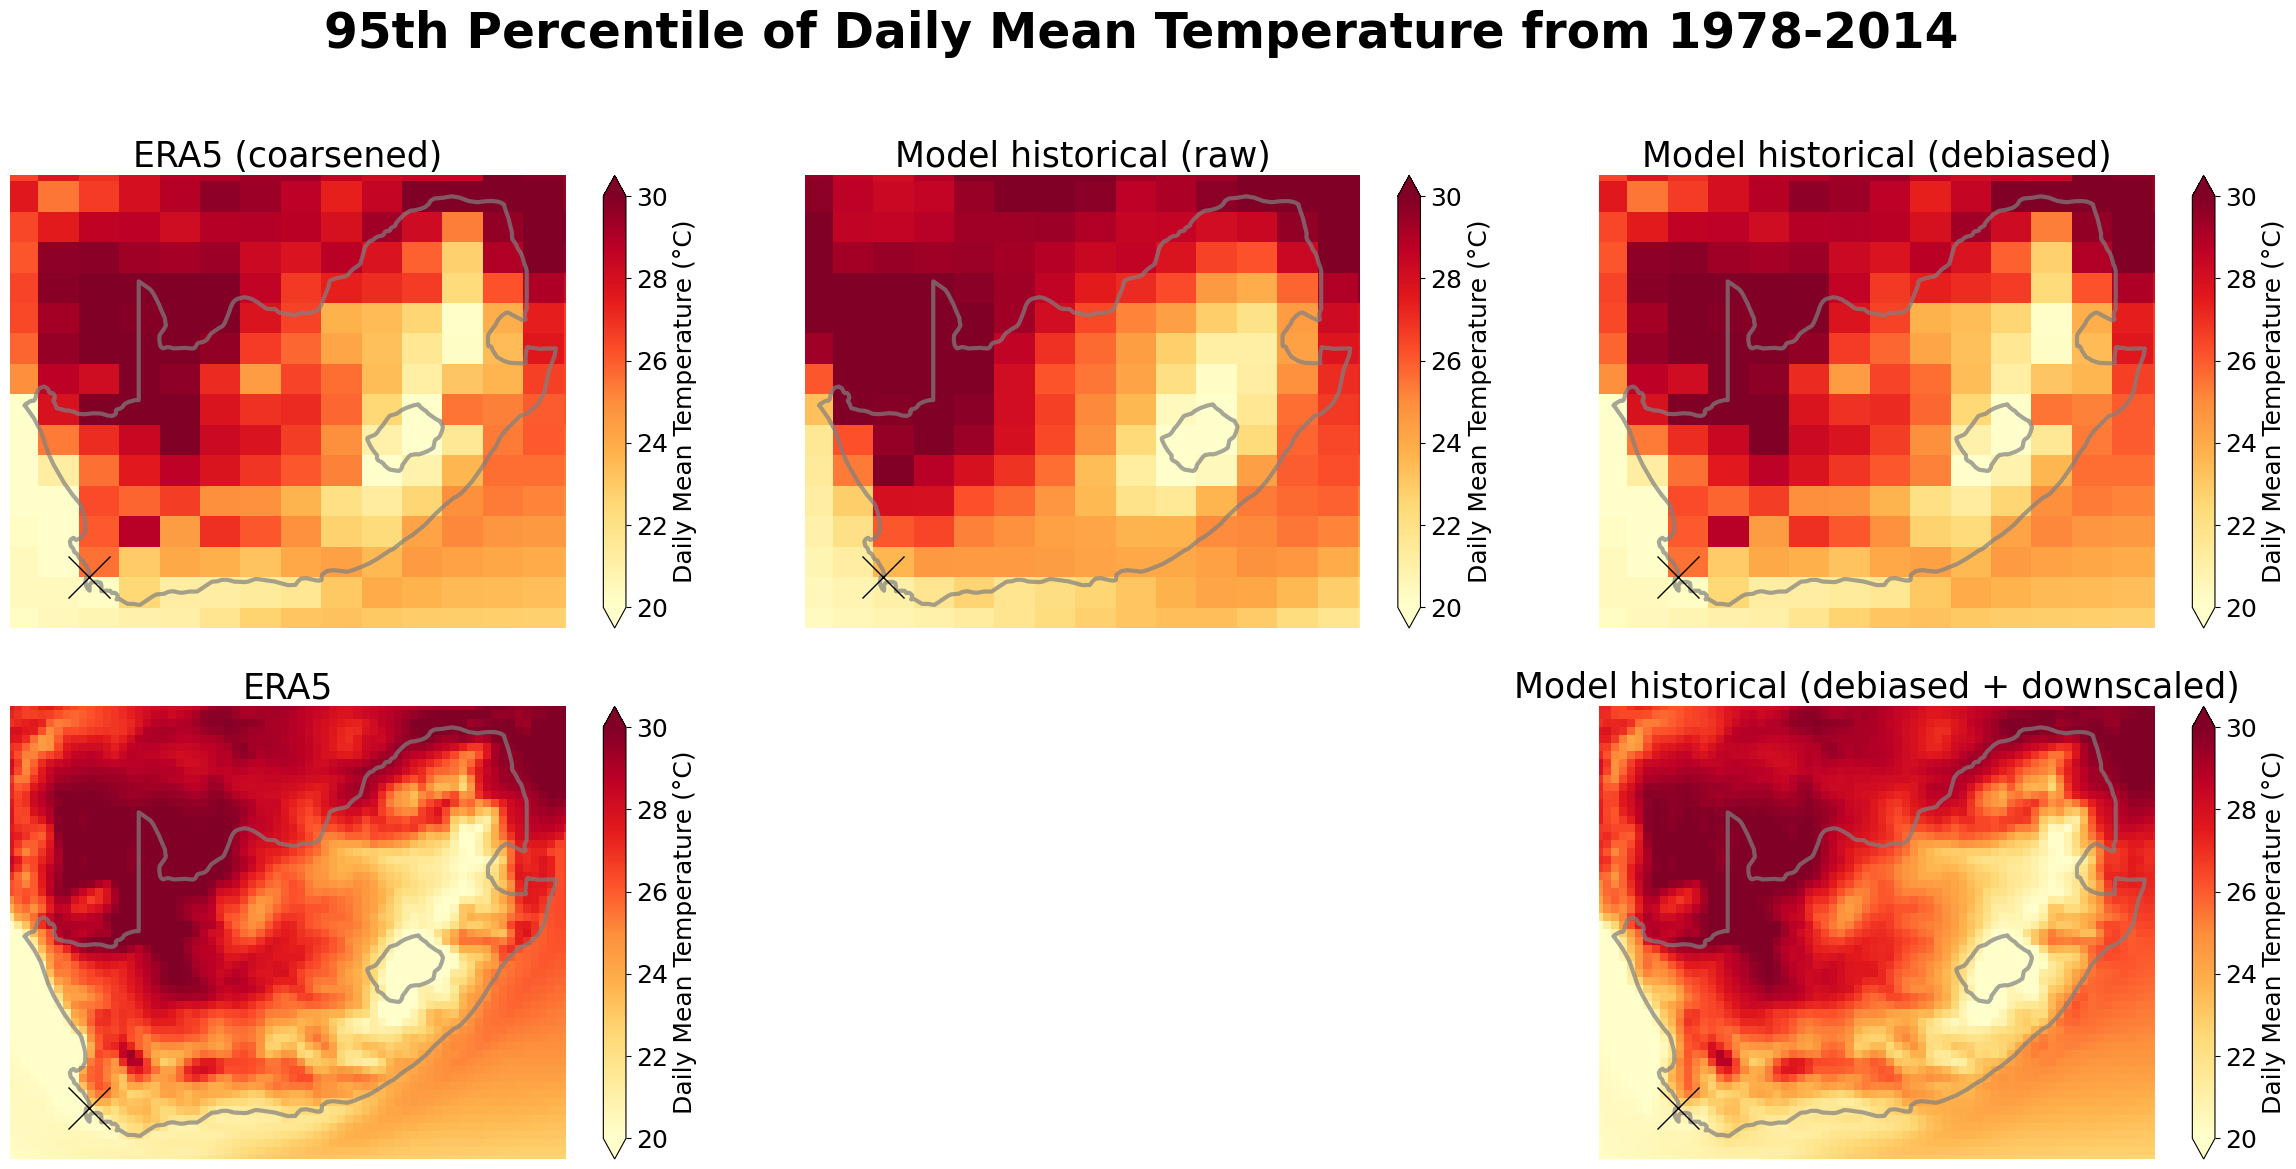

In [32]:
plt.rcParams["font.size"] = 18

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(24, 12))
vmin = 20
vmax = 30
cmap = plt.cm.YlOrRd

for key, title, row, col in plots_info:
    ax = axes[row, col]
    (dict_all[key] - 273.15).quantile(0.95, dim="time").plot(
        ax=ax,
        cmap=cmap,
        add_colorbar=True,
        vmin=vmin,
        vmax=vmax,
        cbar_kwargs={"label": "Daily Mean Temperature (°C)"},
    )
    format_map_subplot(ax)
    ax.set_title(title, fontsize=25)

axes[1, 1].axis("off")
plt.suptitle(
    "95th Percentile of Daily Mean Temperature from 1978-2014",
    fontsize=35,
    fontweight="bold",
)

plt.tight_layout(rect=[0, 0, 1, 0.93], w_pad=1.5, h_pad=3)
plt.show()

# Explore debiased and downscaled temperature changes across scenarios

In [33]:
dict_all["ssp245_debiased_downscaled"] = downscale_from_coarse(
    dict_all["ssp245_debiased"]
)

dict_all["g61pt5k_debiased_downscaled"] = downscale_from_coarse(
    dict_all["g61pt5k_debiased"]
)

In [34]:
plots_info = [
    ("model_hist_debiased_downscaled", "Model historical", 0, 0),
    ("ssp245_debiased_downscaled", "Model SSP245", 0, 1),
    ("g61pt5k_debiased_downscaled", "Model G6-1.5K", 0, 2),
]

In [35]:
delta_ssp245 = dict_all["ssp245_debiased_downscaled"].mean(dim="time") - dict_all[
    "model_hist_debiased_downscaled"
].mean(dim="time")
delta_g61pt5k = dict_all["g61pt5k_debiased_downscaled"].mean(dim="time") - dict_all[
    "model_hist_debiased_downscaled"
].mean(dim="time")

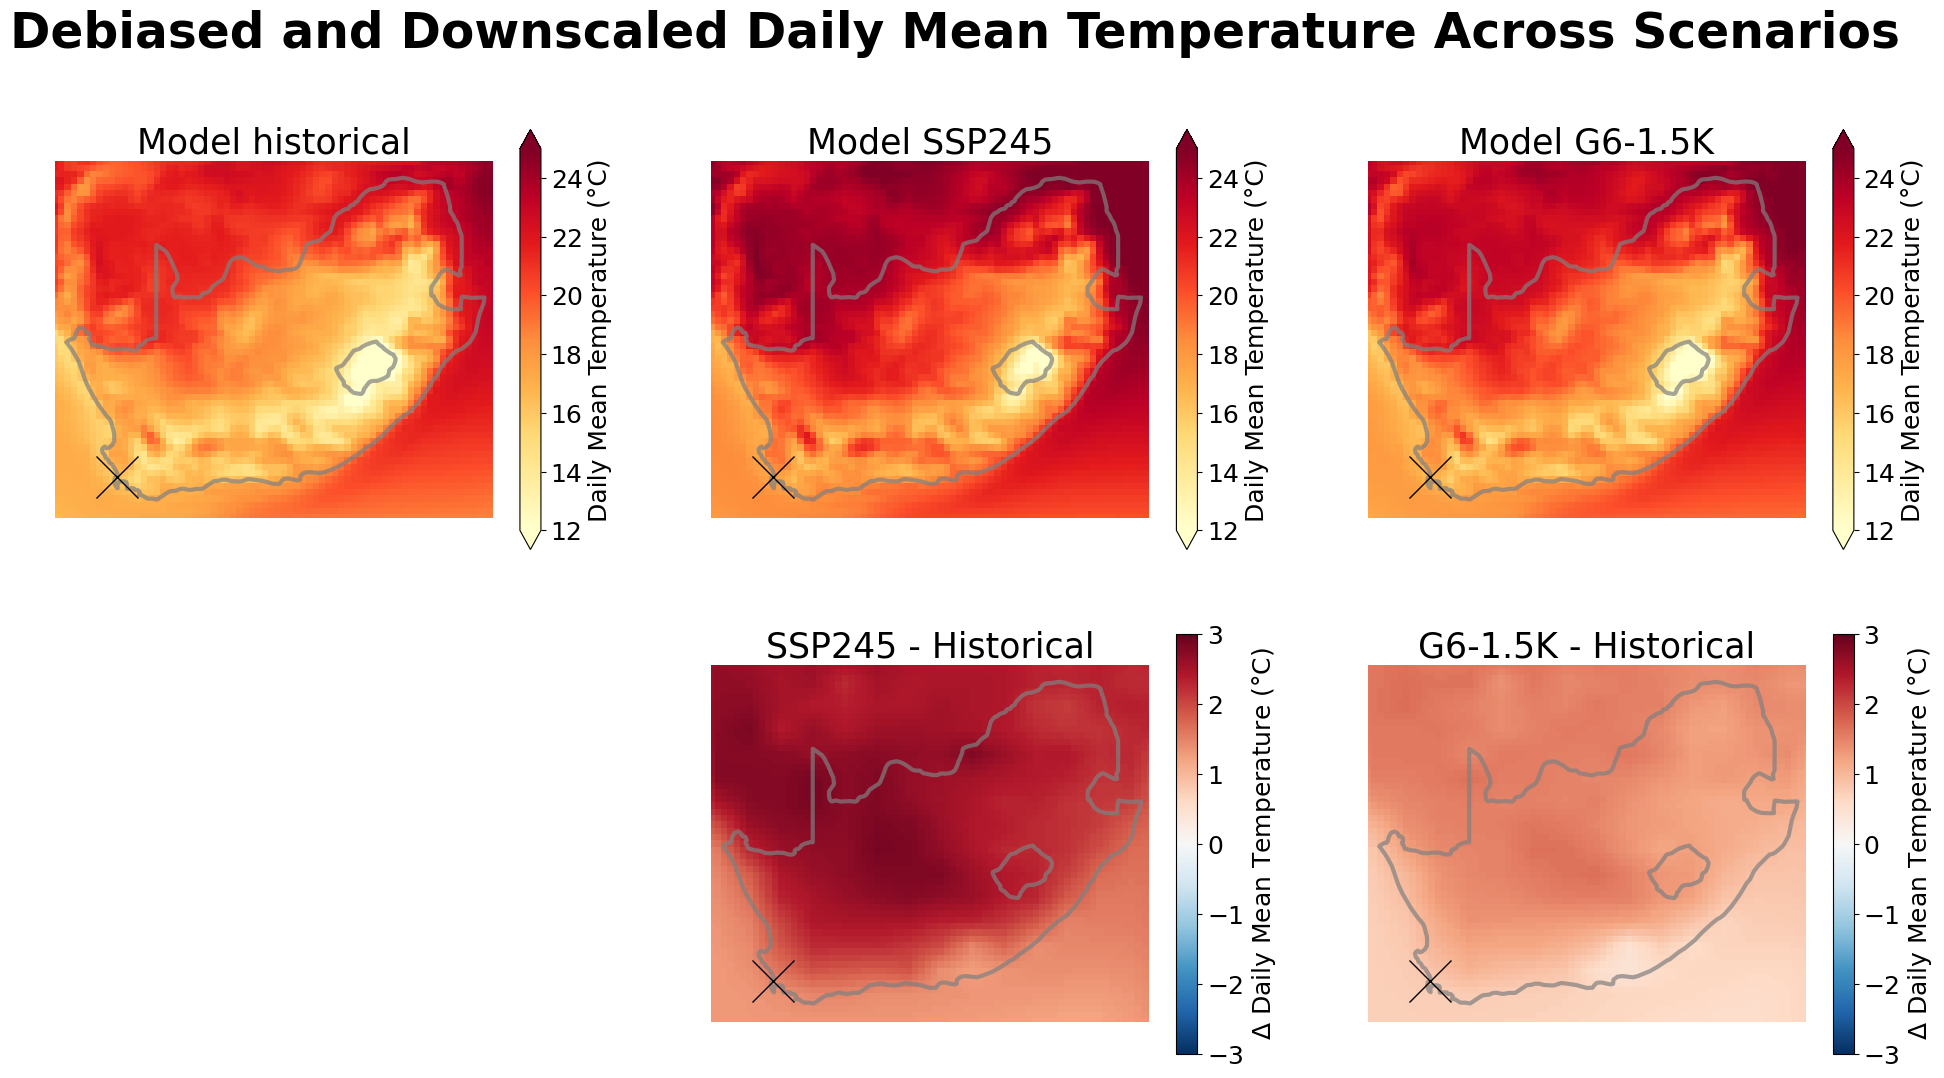

In [36]:
plt.rcParams["font.size"] = 18

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(24, 12))
vmin = 12
vmax = 25
cmap = plt.cm.YlOrRd

for key, title, row, col in plots_info:
    ax = axes[row, col]
    (dict_all[key] - 273.15).mean(dim="time").plot(
        ax=ax,
        cmap=cmap,
        add_colorbar=True,
        vmin=vmin,
        vmax=vmax,
        cbar_kwargs={"label": "Daily Mean Temperature (°C)"},
    )
    format_map_subplot(ax)
    ax.set_title(title, fontsize=25)

ax = axes[1, 1]
delta_ssp245.plot(
    ax=ax,
    cmap=plt.cm.RdBu_r,
    add_colorbar=True,
    vmin=-3,
    vmax=3,
    cbar_kwargs={"label": r"$\Delta$ Daily Mean Temperature (°C)"},
)
ax.set_title("SSP245 - Historical", fontsize=25)
format_map_subplot(ax)

ax = axes[1, 2]
delta_g61pt5k.plot(
    ax=axes[1, 2],
    cmap=plt.cm.RdBu_r,
    add_colorbar=True,
    vmin=-3,
    vmax=3,
    cbar_kwargs={"label": r"$\Delta$ Daily Mean Temperature (°C)"},
)
ax.set_title("G6-1.5K - Historical", fontsize=25)
format_map_subplot(ax)

plt.suptitle(
    "Debiased and Downscaled Daily Mean Temperature Across Scenarios",
    fontsize=35,
    fontweight="bold",
)

axes[1, 0].axis("off")
plt.show()